# Fruit Freshness Detection from Gas Sensors

This notebook loads the gas-sensor recordings in `datasets/`, performs exploratory data analysis, and trains a model whose output is a **freshness score in `[0, 1]`** (1 = fresh, 0 = rotten).

Labels in the current files are binary (`fresh` / `rotten`). The model is therefore a probabilistic classifier: `P(fresh)` is used as the score. Adjacent rows in a recording are highly correlated, so validation holds out **temporal segments** rather than random rows.

Score quality is reported with **ranking** (ROC-AUC, average precision), **probability calibration** (Brier, log loss, ECE), **distance to the 0/1 targets** (MAE, RMSE, R²), and optional **thresholded** metrics at 0.5.

In [ ]:
# !python3 -m venv .venv

In [ ]:
# !source .venv/bin/activate

In [ ]:
# !pip install -r requirements.txt

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    balanced_accuracy_score, mean_absolute_error, mean_squared_error,
    r2_score, roc_auc_score, RocCurveDisplay,
    brier_score_loss, log_loss, average_precision_score, f1_score,
    PrecisionRecallDisplay, calibration_curve
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', context='notebook')

## 1. Load and label the recordings

In [ ]:
DATA_DIR = Path('datasets')
csv_paths = sorted(DATA_DIR.glob('*.csv'))
assert csv_paths, f'No CSV files found in {DATA_DIR.resolve()}'

BASE_SENSORS = ['MQ3', 'MQ5', 'MQ135']
SELECTED_FEATURES = [
    'MQ3_ratio_MQ135', 'MQ3_ratio_MQ5', 'MQ3_minus_MQ5',
    'MQ3_minus_MQ135', 'MQ5_ratio_MQ135', 'sensor_std',
    'MQ5_minus_MQ135', 'MQ5_plus_MQ135', 'MQ3'
]

frames = []
for path in csv_paths:
    if path.name == 'no_fruit.csv':
        raw = pd.read_csv(path).rename(columns={
            'timestamp_ms': 'Ticks',
            'mq3_adc': 'MQ3',
            'mq5_adc': 'MQ5',
            'mq135_adc': 'MQ135',
            'label': 'Class'
        })
        fruit, freshness = 'no_fruit', 'no_fruit'
        is_fresh = np.nan
    else:
        raw = pd.read_csv(path)
        fruit, freshness = path.stem.rsplit('_', 1)
        is_fresh = int(freshness == 'fresh')
    frame = pd.DataFrame({
        'Ticks': raw['Ticks'],
        'MQ3': pd.to_numeric(raw['MQ3']),
        'MQ5': pd.to_numeric(raw['MQ135']),
        'MQ135': pd.to_numeric(raw['MQ5']),
        'Class': raw.get('Class', freshness),
        'source_file': path.name,
        'fruit': fruit,
        'freshness': freshness,
        'is_fresh': is_fresh
    })
    frames.append(frame)

data = pd.concat(frames, ignore_index=True)
sensor_cols = BASE_SENSORS
fruit_data = data[data['freshness'].isin(['fresh', 'rotten'])].copy()

print(f'Recordings including reference: {len(csv_paths)}')
print(f'Rows: {len(data):,}')
print(f'Sensors retained after MQ5/MQ135 swap: {sensor_cols}')
print(f'Reference rows: {(data["freshness"] == "no_fruit").sum():,}')
display(data.head())

Recordings: 16
Rows: 1,240,544
Sensor columns: ['MQ2', 'MQ3', 'MQ4', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ9', 'MQ135']


,Ticks,MQ2,MQ3,MQ4,MQ5,MQ6,MQ7,MQ8,MQ9,MQ135,Class,source_file,fruit,freshness,is_fresh
0,1648641874091,55,114,81,18,73,36,98,47,566,apple_fresh,apple_fresh.csv,apple,fresh,1
1,1648641874105,56,113,68,25,61,33,87,59,555,apple_fresh,apple_fresh.csv,apple,fresh,1
2,1648641874113,50,114,68,23,59,38,89,56,555,apple_fresh,apple_fresh.csv,apple,fresh,1
3,1648641874122,49,111,68,24,54,35,83,53,553,apple_fresh,apple_fresh.csv,apple,fresh,1
4,1648641874130,52,113,70,23,60,35,87,54,552,apple_fresh,apple_fresh.csv,apple,fresh,1


In [32]:
recording_summary = (
    data.groupby(['fruit', 'freshness', 'source_file'], as_index=False)
        .agg(rows=('is_fresh', 'size'), start_tick=('Ticks', 'min'), end_tick=('Ticks', 'max'))
        .sort_values(['fruit', 'freshness'])
)
display(recording_summary)

print('Missing values by column:')
display(data.isna().sum().to_frame('missing_values').T)
print('Class balance:')
display(data['freshness'].value_counts().to_frame('rows'))

,fruit,freshness,source_file,rows,start_tick,end_tick
0,apple,fresh,apple_fresh.csv,77534,1648641372099,1648745817738
1,apple,rotten,apple_rotten.csv,77534,1648839604091,1649012011429
2,banana,fresh,banana_fresh.csv,77534,1648640854091,1648746191426
3,banana,rotten,banana_rotten.csv,77534,1648840100091,1649011561530
4,blueberry,fresh,blueberry_fresh.csv,77534,1648644380099,1648747048886
5,blueberry,rotten,blueberry_rotten.csv,77534,1648841668091,1649012706171
6,grape,fresh,grape_fresh.csv,77534,1648644072091,1648747890877
7,grape,rotten,grape_rotten.csv,77534,1648841462119,1649013182175
8,kiwi,fresh,kiwi_fresh.csv,77534,1648643330099,1648747583258
9,kiwi,rotten,kiwi_rotten.csv,77534,1648841012091,1649012259044


Missing values by column:


,Ticks,MQ2,MQ3,MQ4,MQ5,MQ6,MQ7,MQ8,MQ9,MQ135,Class,source_file,fruit,freshness,is_fresh
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Class balance:


,rows
freshness,
fresh,620272
rotten,620272


## 2. Exploratory data analysis

`Ticks` is a recording timestamp and is excluded from the model. The sensor values are summarized below and then compared by fruit and freshness label.

,count,mean,std,min,25%,50%,75%,max
MQ2,1240544.0,77.08,31.81,30.0,62.0,71.0,81.0,310.0
MQ3,1240544.0,240.86,176.97,53.0,128.0,167.0,270.0,941.0
MQ4,1240544.0,91.71,17.28,49.0,78.0,91.0,102.0,181.0
MQ5,1240544.0,106.36,131.43,0.0,35.0,67.0,111.0,807.0
MQ6,1240544.0,107.50,79.73,42.0,74.0,89.0,105.0,590.0
MQ7,1240544.0,67.09,29.70,19.0,50.0,62.0,72.0,255.0
MQ8,1240544.0,230.90,190.18,41.0,111.0,179.0,251.0,1126.0
MQ9,1240544.0,92.25,55.97,35.0,67.0,82.0,95.0,482.0
MQ135,1240544.0,974.78,486.09,434.0,680.0,800.0,1097.0,2975.0


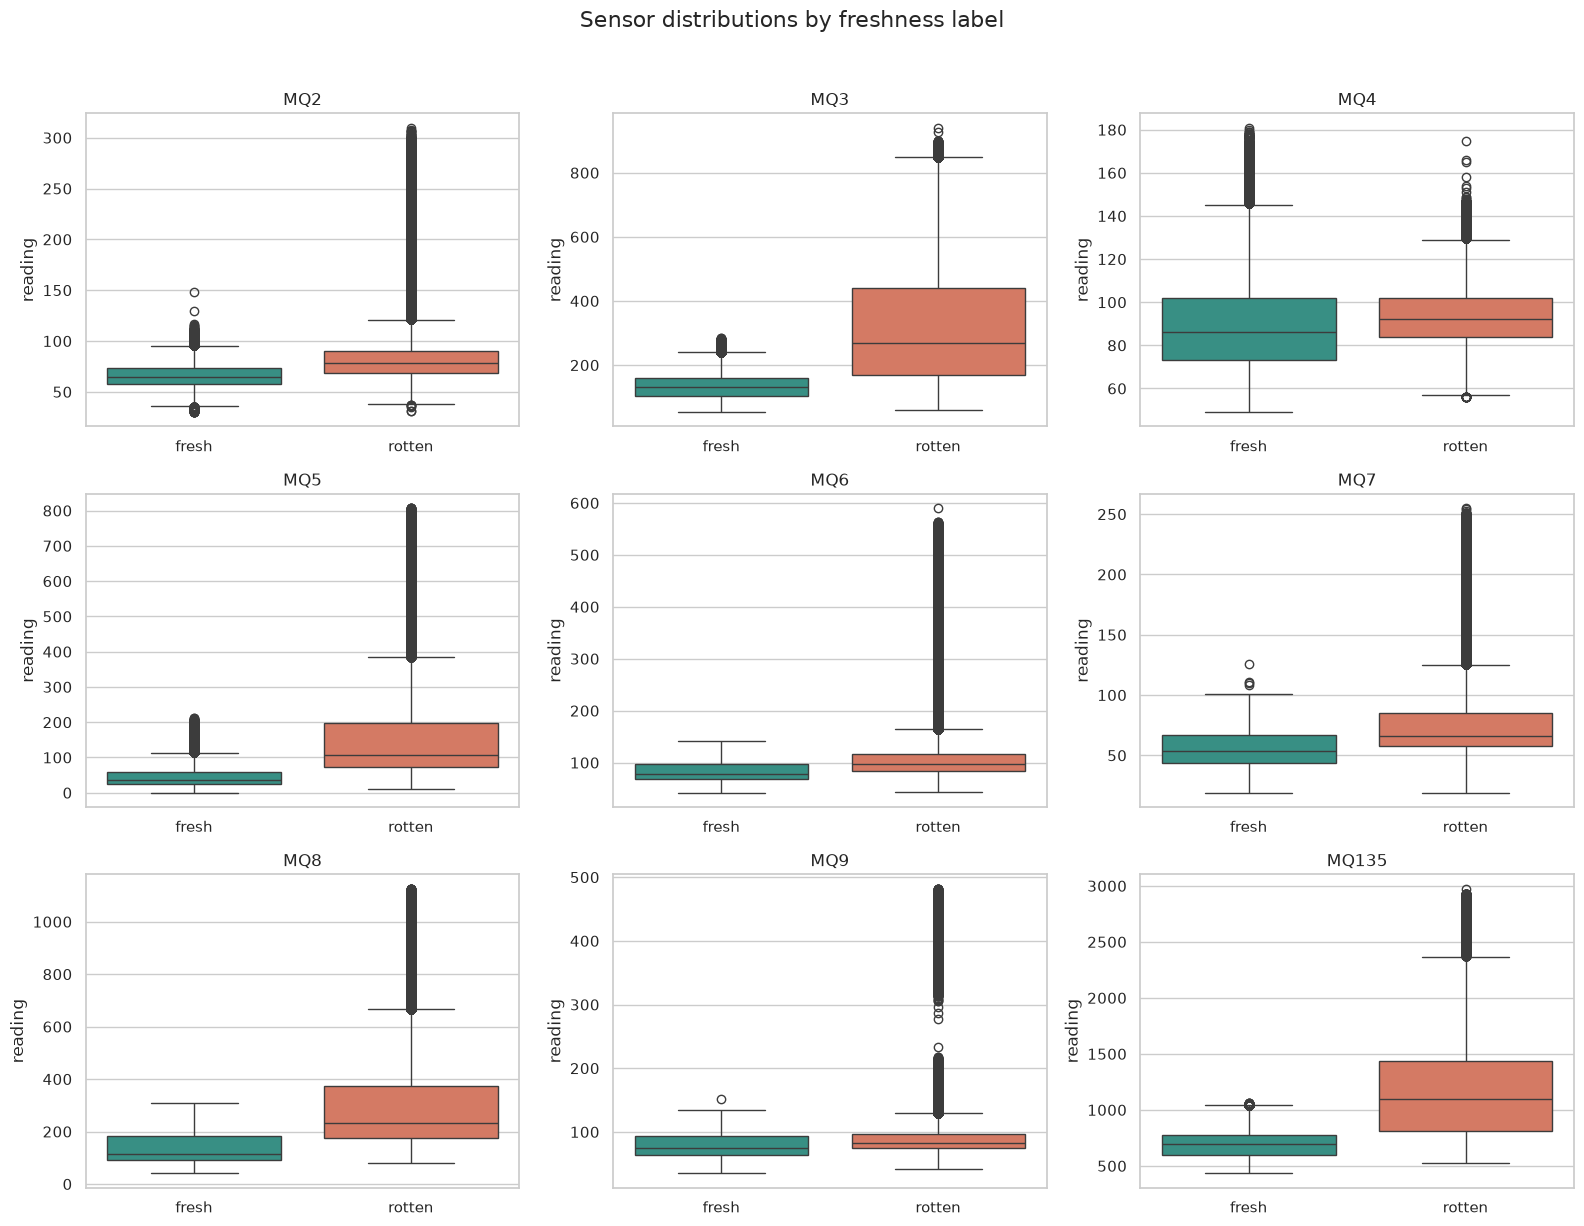

In [ ]:
display(data[sensor_cols].describe().T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, sensor in zip(axes, sensor_cols):
    sns.boxplot(data=fruit_data, x='freshness', y=sensor, hue='freshness',
                order=['fresh', 'rotten'], palette={'fresh': '#2a9d8f', 'rotten': '#e76f51'},
                legend=False, ax=ax)
    ax.set_title(f'{sensor} after MQ5/MQ135 swap')
    ax.set_xlabel('')
    ax.set_ylabel('reading')
plt.tight_layout()
plt.show()

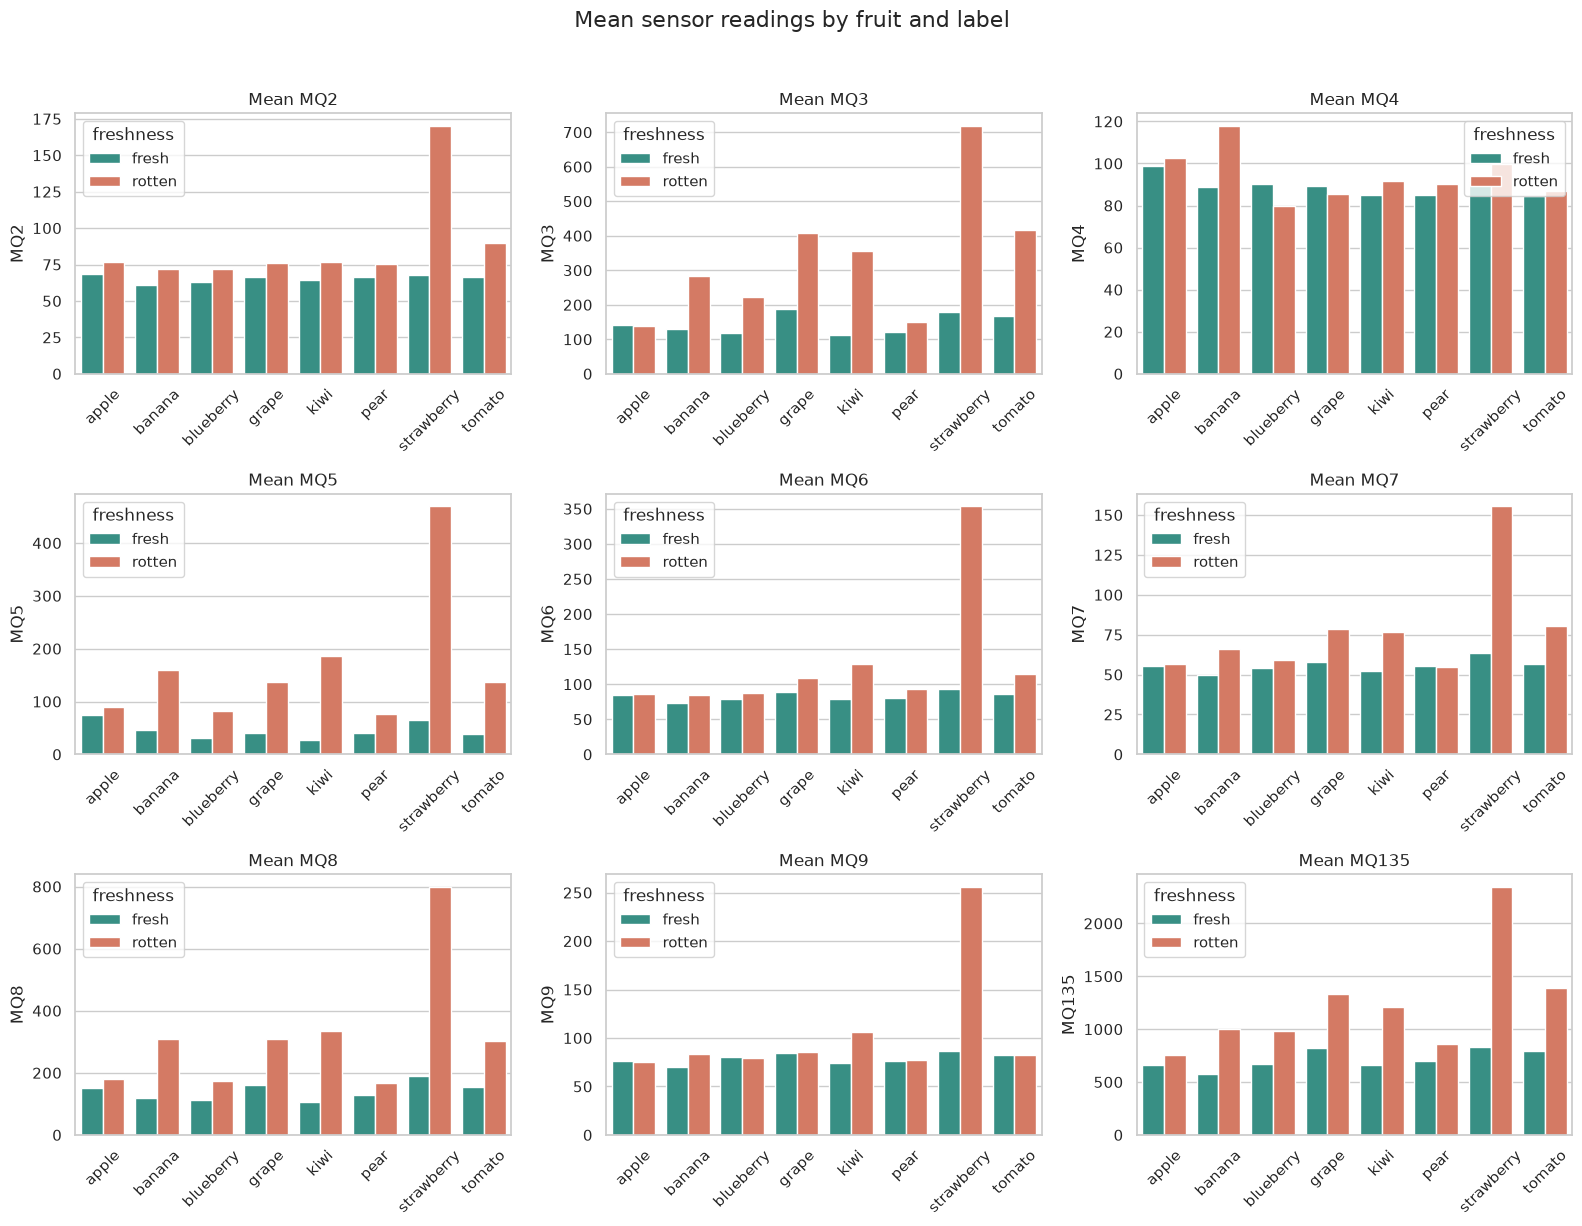

In [ ]:
mean_by_group = fruit_data.groupby(['fruit', 'freshness'])[sensor_cols].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, sensor in zip(axes, sensor_cols):
    sns.barplot(data=mean_by_group, x='fruit', y=sensor, hue='freshness',
                hue_order=['fresh', 'rotten'],
                palette={'fresh': '#2a9d8f', 'rotten': '#e76f51'}, ax=ax)
    ax.set_title(f'Mean {sensor} after swap')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

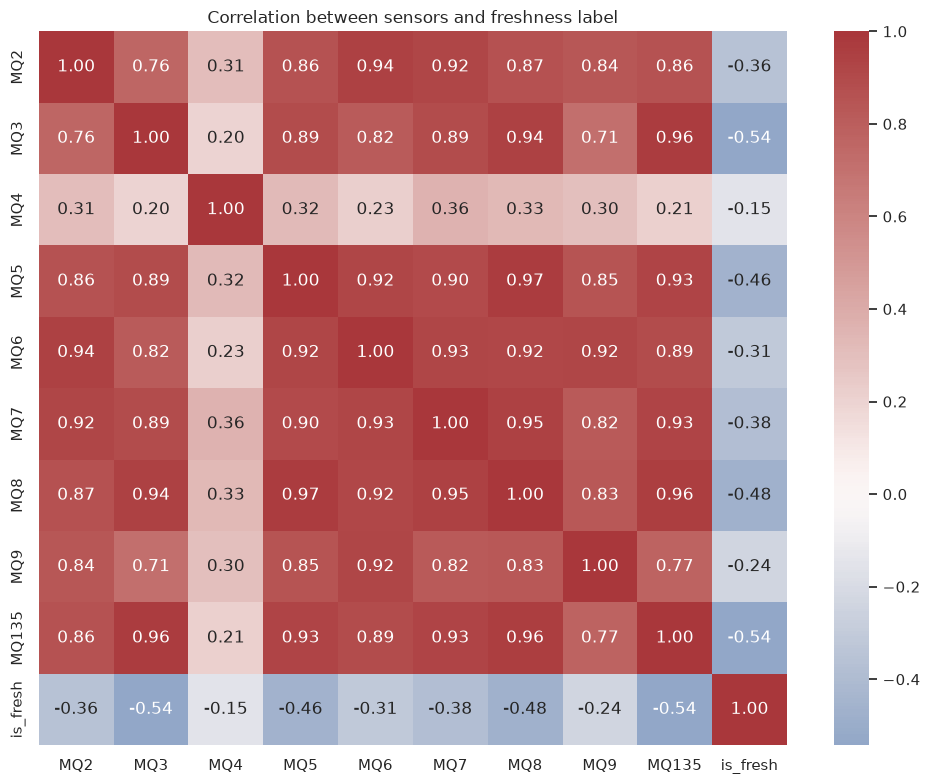

In [35]:
plt.figure(figsize=(10, 8))
corr = data[sensor_cols + ['is_fresh']].corr()
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Correlation between sensors and freshness label')
plt.tight_layout()
plt.show()

## 3. Prepare a modeling sample

Each file contains many sequential readings from one recording. We retain at most 3,000 evenly spaced rows per file for a manageable, balanced modeling table. The file-level fruit name becomes the validation group, while no timestamps or source metadata are passed to the estimator.

In [ ]:
MAX_ROWS_PER_RECORDING = 3000
fruit_data = data[data['freshness'].isin(['fresh', 'rotten'])].copy()
sampled_frames = []
for frame in [group for _, group in fruit_data.groupby('source_file', sort=True)]:
    step = max(1, len(frame) // MAX_ROWS_PER_RECORDING)
    sampled = frame.iloc[::step].head(MAX_ROWS_PER_RECORDING).copy()
    sampled['recording'] = sampled['source_file']
    sampled['segment'] = np.arange(len(sampled)) // 300
    sampled_frames.append(sampled)

model_data = pd.concat(sampled_frames, ignore_index=True)

def make_selected_features(frame):
    raw = frame[BASE_SENSORS].astype(float)
    features = pd.DataFrame(index=frame.index)
    features['MQ3_ratio_MQ135'] = raw['MQ3'] / (raw['MQ135'] + 1e-6)
    features['MQ3_ratio_MQ5'] = raw['MQ3'] / (raw['MQ5'] + 1e-6)
    features['MQ3_minus_MQ5'] = raw['MQ3'] - raw['MQ5']
    features['MQ3_minus_MQ135'] = raw['MQ3'] - raw['MQ135']
    features['MQ5_ratio_MQ135'] = raw['MQ5'] / (raw['MQ135'] + 1e-6)
    features['sensor_std'] = raw.std(axis=1)
    features['MQ5_minus_MQ135'] = raw['MQ5'] - raw['MQ135']
    features['MQ5_plus_MQ135'] = raw['MQ5'] + raw['MQ135']
    features['MQ3'] = raw['MQ3']
    return features.replace([np.inf, -np.inf], np.nan).fillna(0.0)[SELECTED_FEATURES]

X = make_selected_features(model_data)
y = model_data['is_fresh'].astype(int)
fruit_target = model_data['fruit']
recording_groups = model_data['recording'] + '_segment_' + model_data['segment'].astype(str)
fruit_groups = model_data['fruit']

print(f'Modeling rows: {len(model_data):,}')
print(f'Feature count: {X.shape[1]}')
print(f'Features: {SELECTED_FEATURES}')
print(f'Rows per fruit: {fruit_groups.value_counts().sort_index().to_dict()}')
print(f'Temporal validation groups: {recording_groups.nunique():,}')
display(pd.crosstab(model_data['fruit'], model_data['freshness']))


def expected_calibration_error(y_true, y_score, n_bins=10):
    """Weighted absolute gap between bin confidence and empirical freshness rate."""
    y_true = np.asarray(y_true, dtype=float)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0.0, 1.0)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_score, bins, right=False) - 1, 0, n_bins - 1)
    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not np.any(mask):
            continue
        ece += mask.mean() * abs(y_true[mask].mean() - y_score[mask].mean())
    return float(ece)


def evaluate_freshness_score(y_true, y_score, threshold=0.5):
    """Metrics for a [0, 1] freshness score trained against binary fresh/rotten labels."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0.0, 1.0)
    y_pred = (y_score >= threshold).astype(int)
    both_classes = np.unique(y_true).size > 1
    metrics = {
        'brier': brier_score_loss(y_true, y_score),
        'log_loss': log_loss(y_true, y_score, labels=[0, 1]),
        'mae': mean_absolute_error(y_true, y_score),
        'rmse': mean_squared_error(y_true, y_score) ** 0.5,
        'r2': r2_score(y_true, y_score),
        'roc_auc': roc_auc_score(y_true, y_score) if both_classes else np.nan,
        'average_precision': average_precision_score(y_true, y_score) if both_classes else np.nan,
        'ece_10': expected_calibration_error(y_true, y_score, n_bins=10),
        'threshold_accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'score_min': float(y_score.min()),
        'score_max': float(y_score.max()),
        'mean_score_rotten': float(y_score[y_true == 0].mean()) if np.any(y_true == 0) else np.nan,
        'mean_score_fresh': float(y_score[y_true == 1].mean()) if np.any(y_true == 1) else np.nan,
    }
    return metrics


def per_group_freshness_metrics(y_true, y_score, groups):
    rows = []
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    groups = np.asarray(groups)
    for group in pd.unique(groups):
        mask = groups == group
        row = evaluate_freshness_score(y_true[mask], y_score[mask])
        row['group'] = group
        row['n'] = int(mask.sum())
        rows.append(row)
    return pd.DataFrame(rows).set_index('group')

Modeling rows: 48,000
Rows per fruit: {'apple': 6000, 'banana': 6000, 'blueberry': 6000, 'grape': 6000, 'kiwi': 6000, 'pear': 6000, 'strawberry': 6000, 'tomato': 6000}
Temporal validation groups: 160


freshness,fresh,rotten
fruit,,
apple,3000,3000
banana,3000,3000
blueberry,3000,3000
grape,3000,3000
kiwi,3000,3000
pear,3000,3000
strawberry,3000,3000
tomato,3000,3000


## 4. Train and evaluate models

The evaluation holds out complete temporal segments from every recording so adjacent samples do not leak into the test set.

Because the deployment output is a continuous score, models are ranked primarily by **Brier score** (mean squared error of `P(fresh)` versus the 0/1 label) and **ROC-AUC**. Accuracy at 0.5 is reported only as an operational snapshot.

In [ ]:
segment_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(segment_splitter.split(X, y, groups=recording_groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f'Train rows: {len(train_idx):,}; test rows: {len(test_idx):,}')
print(f'Train segments: {recording_groups.iloc[train_idx].nunique():,}; test segments: {recording_groups.iloc[test_idx].nunique():,}')

models = {
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.08,
        loss_function='Logloss', verbose=False, random_seed=42,
        thread_count=-1, allow_writing_files=False
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, min_samples_leaf=2, max_features=1.0,
        n_jobs=-1, random_state=42, class_weight='balanced'
    ),
    'Logistic regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

results = []
freshness_scores = {}
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    score = estimator.predict_proba(X_test)[:, 1]
    freshness_scores[name] = score
    metrics = evaluate_freshness_score(y_test, score)
    metrics['model'] = name
    metrics['score_range'] = f'[{score.min():.3f}, {score.max():.3f}]'
    results.append(metrics)

results_df = (
    pd.DataFrame(results)
    .sort_values(['brier', 'roc_auc'], ascending=[True, False])
    .reset_index(drop=True)
)
display_cols = [
    'model', 'score_range', 'brier', 'log_loss', 'ece_10', 'roc_auc',
    'average_precision', 'mae', 'rmse', 'r2', 'threshold_accuracy',
    'balanced_accuracy', 'f1'
]
display(results_df[display_cols].round(4))
assert all((score >= 0).all() and (score <= 1).all() for score in freshness_scores.values())

Train rows: 38,400; test rows: 9,600
Train segments: 128; test segments: 32


,model,accuracy,balanced_accuracy,roc_auc
0,CatBoost,0.951,0.955,0.995
1,Extra Trees,0.950,0.955,0.995
2,Logistic regression,0.854,0.861,0.941


Best model: CatBoost
Segment-held-out accuracy: 0.951
              precision    recall  f1-score   support

      rotten       0.99      0.92      0.95      5400
       fresh       0.90      0.99      0.95      4200

    accuracy                           0.95      9600
   macro avg       0.95      0.96      0.95      9600
weighted avg       0.95      0.95      0.95      9600



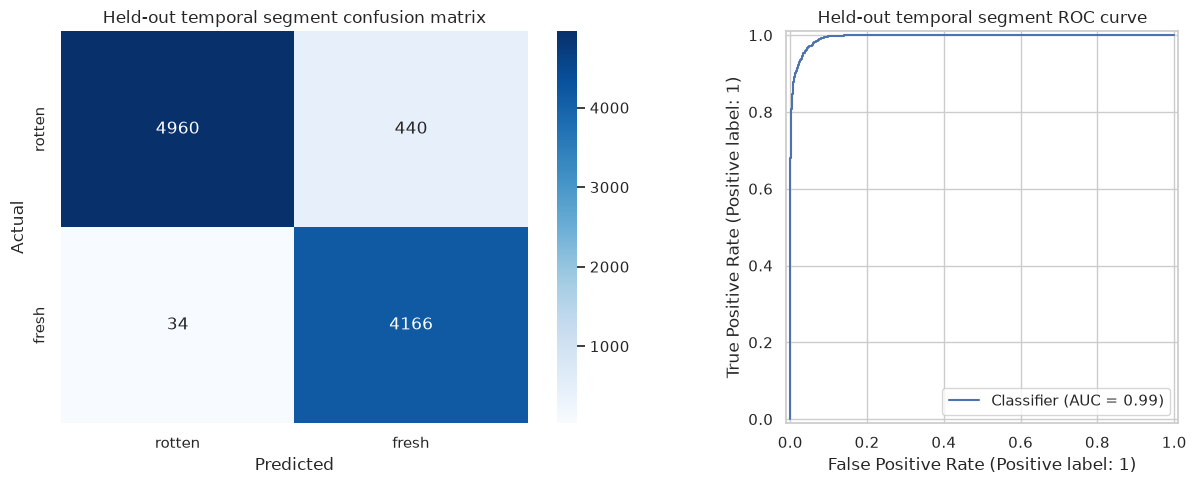

In [ ]:
best_name = results_df.iloc[0]['model']
best_model = models[best_name]
best_score = freshness_scores[best_name]
best_metrics = evaluate_freshness_score(y_test, best_score)
best_predictions = (best_score >= 0.5).astype(int)

print(f'Best score model (lowest Brier): {best_name}')
for key in [
    'brier', 'log_loss', 'ece_10', 'roc_auc', 'average_precision',
    'mae', 'rmse', 'r2', 'threshold_accuracy', 'balanced_accuracy', 'f1',
    'mean_score_rotten', 'mean_score_fresh'
]:
    print(f'{key}: {best_metrics[key]:.4f}')
print(classification_report(y_test, best_predictions, target_names=['rotten', 'fresh']))

print('Per-fruit score metrics on held-out segments:')
fruit_metrics = per_group_freshness_metrics(
    y_test, best_score, fruit_groups.iloc[test_idx].to_numpy()
)
display(fruit_metrics[[
    'n', 'brier', 'roc_auc', 'average_precision', 'ece_10',
    'mae', 'balanced_accuracy', 'mean_score_rotten', 'mean_score_fresh'
]].round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
sns.histplot(
    x=best_score, hue=np.where(y_test.to_numpy() == 1, 'fresh', 'rotten'),
    bins=20, stat='density', common_norm=False, ax=axes[0, 0]
)
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_title(f'{best_name}: score by true label')
axes[0, 0].set_xlabel('predicted freshness score')

RocCurveDisplay.from_predictions(y_test, best_score, ax=axes[0, 1])
axes[0, 1].set_title('ROC curve (ranking of freshness)')

PrecisionRecallDisplay.from_predictions(y_test, best_score, ax=axes[1, 0])
axes[1, 0].set_title('Precision-recall curve')

frac_pos, mean_pred = calibration_curve(y_test, best_score, n_bins=10, strategy='uniform')
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect calibration')
axes[1, 1].plot(mean_pred, frac_pos, marker='o', label=best_name)
axes[1, 1].set_xlabel('mean predicted freshness score')
axes[1, 1].set_ylabel('empirical P(fresh)')
axes[1, 1].set_title('Reliability diagram')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, best_predictions)
cm_df = pd.DataFrame(cm, index=['true rotten', 'true fresh'], columns=['pred rotten', 'pred fresh'])
display(cm_df)

How to read the score metrics:

- **ROC-AUC / average precision**: ranking quality — fresh samples should get higher scores than rotten ones.
- **Brier / log loss / ECE**: whether the number itself is a trustworthy probability, not just a ranking.
- **MAE / RMSE / R²**: distance from the binary 0/1 targets; useful until ordinal labels (e.g. `starts_to_spoil`) exist.
- **Balanced accuracy / F1 at 0.5**: optional operating point for a FRESH / SPOILED display. Do not use accuracy alone if classes are imbalanced or the score is poorly calibrated.


## 11. Arduino Uno export

The final nine-feature TinyML models are trained on all sampled rows and exported by `export_arduino_model.py` into `arduino_sketches/freshness_tinyml_uno/`. The generated sketch stores int8 weights in `PROGMEM`, uses the `MQ3`/`MQ5`/`MQ135` analog inputs, and contains separate freshness and fruit-type output heads sized for Arduino Uno flash and SRAM limits.

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

TINYML_MAX_DEPTH = 6
tiny_freshness_model = DecisionTreeClassifier(
    max_depth=TINYML_MAX_DEPTH,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
tiny_fruit_model = DecisionTreeClassifier(
    max_depth=TINYML_MAX_DEPTH,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

tiny_freshness_model.fit(X_train, y_train)
tiny_fruit_model.fit(X.iloc[train_idx], fruit_target.iloc[train_idx])

tiny_freshness_predictions = tiny_freshness_model.predict(X_test)
tiny_fruit_predictions = tiny_fruit_model.predict(X.iloc[test_idx])

tiny_freshness_accuracy = accuracy_score(y_test, tiny_freshness_predictions)
tiny_fruit_accuracy = accuracy_score(fruit_target.iloc[test_idx], tiny_fruit_predictions)
tiny_joint_accuracy = (
    (tiny_freshness_predictions == y_test.to_numpy())
    & (tiny_fruit_predictions == fruit_target.iloc[test_idx].to_numpy())
).mean()

tinyml_results = pd.DataFrame([
    {
        'target': 'freshness',
        'model': 'TinyML decision tree',
        'accuracy': tiny_freshness_accuracy,
        'nodes': tiny_freshness_model.tree_.node_count,
        'max_depth': tiny_freshness_model.tree_.max_depth
    },
    {
        'target': 'fruit type',
        'model': 'TinyML decision tree',
        'accuracy': tiny_fruit_accuracy,
        'nodes': tiny_fruit_model.tree_.node_count,
        'max_depth': tiny_fruit_model.tree_.max_depth
    },
    {
        'target': 'fruit + freshness',
        'model': 'TinyML decision trees',
        'accuracy': tiny_joint_accuracy,
        'nodes': tiny_freshness_model.tree_.node_count + tiny_fruit_model.tree_.node_count,
        'max_depth': TINYML_MAX_DEPTH
    }
])

display(tinyml_results.style.format({'accuracy': '{:.3f}'}))
print(f'TinyML freshness accuracy: {tiny_freshness_accuracy:.3f}')
print(f'TinyML fruit-type accuracy: {tiny_fruit_accuracy:.3f}')
print(f'TinyML exact joint accuracy: {tiny_joint_accuracy:.3f}')
print(f'Total decision-tree nodes: {tinyml_results.iloc[2]["nodes"]}')

,target,model,accuracy,nodes,max_depth
0,freshness,TinyML decision tree,0.923,73,6
1,fruit type,TinyML decision tree,0.648,107,6
2,fruit + freshness,TinyML decision trees,0.600,180,6


TinyML freshness accuracy: 0.923
TinyML fruit-type accuracy: 0.648
TinyML exact joint accuracy: 0.600
Total decision-tree nodes: 180


In [41]:
optimized_freshness_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(20,), activation='relu', alpha=0.001,
        batch_size=256, max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42
    ))
])
optimized_fruit_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(16, 8), activation='relu', alpha=0.001,
        batch_size=256, max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42
    ))
])

optimized_freshness_model.fit(X_train, y_train)
optimized_fruit_model.fit(X.iloc[train_idx], fruit_target.iloc[train_idx])

optimized_freshness_predictions = optimized_freshness_model.predict(X_test)
optimized_fruit_predictions = optimized_fruit_model.predict(X.iloc[test_idx])
optimized_freshness_accuracy = accuracy_score(y_test, optimized_freshness_predictions)
optimized_fruit_accuracy = accuracy_score(
    fruit_target.iloc[test_idx], optimized_fruit_predictions
)
optimized_joint_accuracy = (
    (optimized_freshness_predictions == y_test.to_numpy())
    & (optimized_fruit_predictions == fruit_target.iloc[test_idx].to_numpy())
).mean()

def parameter_count(model):
    return int(sum(weights.size + biases.size
                   for weights, biases in zip(
                       model.named_steps['model'].coefs_,
                       model.named_steps['model'].intercepts_)))

def quantized_footprint(model, input_features):
    neural_net = model.named_steps['model']
    weight_bytes = sum(weights.size for weights in neural_net.coefs_)
    bias_bytes = 4 * sum(biases.size for biases in neural_net.intercepts_)
    scaler_bytes = 2 * input_features * 4  # float32 mean and inverse scale
    quantization_scale_bytes = 4 * len(neural_net.coefs_)  # float32 per layer
    largest_layer = max(input_features, *(weights.shape[1] for weights in neural_net.coefs_))
    activation_bytes = 2 * largest_layer * 2  # two int16 ping-pong buffers
    static_bytes = weight_bytes + bias_bytes + scaler_bytes + quantization_scale_bytes + activation_bytes
    return {
        'parameters': parameter_count(model),
        'int8_weights': weight_bytes,
        'int32_biases': bias_bytes,
        'scaler_constants': scaler_bytes,
        'quantization_scales': quantization_scale_bytes,
        'activation_buffers': activation_bytes,
        'static_bytes': static_bytes
    }

freshness_footprint = quantized_footprint(optimized_freshness_model, len(sensor_cols))
fruit_footprint = quantized_footprint(optimized_fruit_model, len(sensor_cols))
total_static_bytes = freshness_footprint['static_bytes'] + fruit_footprint['static_bytes']
ESP32_TINYML_BUDGET_BYTES = 32 * 1024
assert total_static_bytes < ESP32_TINYML_BUDGET_BYTES

optimized_tinyml_results = pd.DataFrame([
    {
        'target': 'freshness',
        'model': 'Quantized MLP',
        'accuracy': optimized_freshness_accuracy,
        'parameters': freshness_footprint['parameters'],
        'estimated_static_bytes': freshness_footprint['static_bytes']
    },
    {
        'target': 'fruit type',
        'model': 'Quantized MLP',
        'accuracy': optimized_fruit_accuracy,
        'parameters': fruit_footprint['parameters'],
        'estimated_static_bytes': fruit_footprint['static_bytes']
    },
    {
        'target': 'fruit + freshness',
        'model': 'Two quantized MLPs',
        'accuracy': optimized_joint_accuracy,
        'parameters': freshness_footprint['parameters'] + fruit_footprint['parameters'],
        'estimated_static_bytes': total_static_bytes
    }
])

display(optimized_tinyml_results.style.format({'accuracy': '{:.3f}'}))
print(f'Optimized TinyML freshness accuracy: {optimized_freshness_accuracy:.3f}')
print(f'Optimized TinyML fruit-type accuracy: {optimized_fruit_accuracy:.3f}')
print(f'Optimized TinyML exact joint accuracy: {optimized_joint_accuracy:.3f}')
print(f'Total trainable parameters: {freshness_footprint["parameters"] + fruit_footprint["parameters"]:,}')
print(f'Estimated quantized static footprint: {total_static_bytes:,} bytes')
print(f'ESP32 TinyML budget: {ESP32_TINYML_BUDGET_BYTES:,} bytes')
print(f'Estimated budget usage: {100 * total_static_bytes / ESP32_TINYML_BUDGET_BYTES:.2f}%')

,target,model,accuracy,parameters,estimated_static_bytes
0,freshness,Quantized MLP,0.947,221,444
1,fruit type,Quantized MLP,0.950,368,612
2,fruit + freshness,Two quantized MLPs,0.900,589,1056


Optimized TinyML freshness accuracy: 0.947
Optimized TinyML fruit-type accuracy: 0.950
Optimized TinyML exact joint accuracy: 0.900
Total trainable parameters: 589
Estimated quantized static footprint: 1,056 bytes
ESP32 TinyML budget: 32,768 bytes
Estimated budget usage: 3.22%


,importance
MQ135,29.077720
MQ3,20.591818
MQ5,10.227514
MQ9,10.209660
MQ8,9.604607
MQ4,8.375873
MQ7,6.266834
MQ6,3.018108
MQ2,2.627868


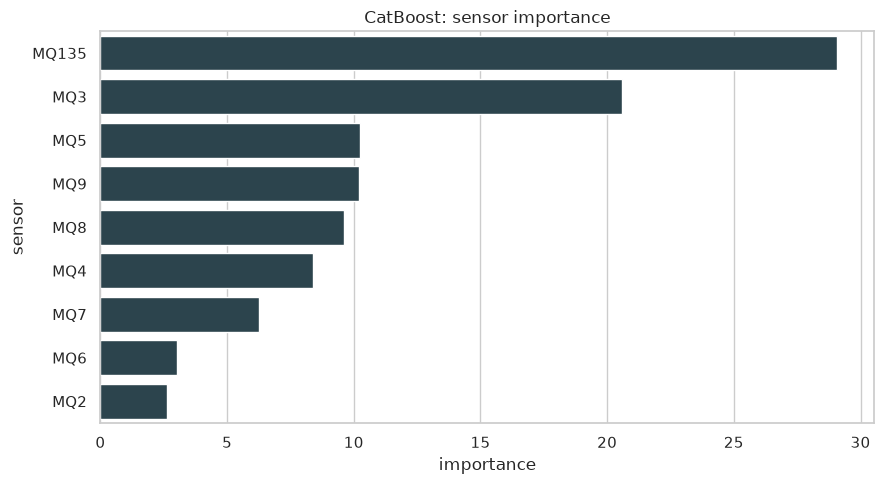

In [ ]:
if best_name in {'CatBoost', 'Extra Trees'}:
    importance = pd.Series(best_model.feature_importances_, index=SELECTED_FEATURES)
else:
    importance = pd.Series(
        np.abs(best_model.named_steps['model'].coef_[0]), index=SELECTED_FEATURES
    )

importance = importance.sort_values(ascending=False)
display(importance.to_frame('importance'))

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values, y=importance.index, color='#264653')
plt.title(f'{best_name}: nine-feature importance')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

## 6. Sensor ablation

Sensors are ranked by the trained CatBoost freshness model's feature importance, from least to most important. The optimized TinyML MLPs are retrained after removing one additional low-importance sensor at each step. Evaluation stops at the first point where freshness accuracy falls below 90%.

In [43]:
# least_to_most_important = importance.sort_values(ascending=True).index.tolist()
# print('Sensors removed in order:', least_to_most_important)

# sensor_ablation_rows = []
# discarded_sensors = []
# for discard_count in range(len(sensor_cols)):
#     if discard_count:
#         discarded_sensors.append(least_to_most_important[discard_count - 1])
#     remaining_sensors = [sensor for sensor in sensor_cols if sensor not in discarded_sensors]

#     ablation_freshness_model = Pipeline([
#         ('scale', StandardScaler()),
#         ('model', MLPClassifier(
#             hidden_layer_sizes=(20,), activation='relu', alpha=0.001,
#             batch_size=256, max_iter=300, early_stopping=True,
#             validation_fraction=0.1, n_iter_no_change=15,
#             random_state=42
#         ))
#     ])
#     ablation_fruit_model = Pipeline([
#         ('scale', StandardScaler()),
#         ('model', MLPClassifier(
#             hidden_layer_sizes=(16, 8), activation='relu', alpha=0.001,
#             batch_size=256, max_iter=300, early_stopping=True,
#             validation_fraction=0.1, n_iter_no_change=15,
#             random_state=42
#         ))
#     ])
#     ablation_freshness_model.fit(X_train[remaining_sensors], y_train)
#     ablation_fruit_model.fit(X.iloc[train_idx][remaining_sensors], fruit_target.iloc[train_idx])
#     freshness_predictions = ablation_freshness_model.predict(X_test[remaining_sensors])
#     fruit_predictions = ablation_fruit_model.predict(X.iloc[test_idx][remaining_sensors])
#     freshness_accuracy = accuracy_score(y_test, freshness_predictions)
#     fruit_accuracy = accuracy_score(fruit_target.iloc[test_idx], fruit_predictions)
#     joint_accuracy = (
#         (freshness_predictions == y_test.to_numpy())
#         & (fruit_predictions == fruit_target.iloc[test_idx].to_numpy())
#     ).mean()
#     sensor_ablation_rows.append({
#         'discarded_count': discard_count,
#         'discarded_sensors': ', '.join(discarded_sensors) or 'none',
#         'remaining_sensors': ', '.join(remaining_sensors),
#         'freshness_accuracy': freshness_accuracy,
#         'fruit_type_accuracy': fruit_accuracy,
#         'joint_accuracy': joint_accuracy
#     })
#     if freshness_accuracy < 0.90:
#         break

# sensor_ablation_results = pd.DataFrame(sensor_ablation_rows)
# display(sensor_ablation_results.round(3))
# first_below_90 = sensor_ablation_results.iloc[-1]
# print(f'First freshness accuracy below 90%: {first_below_90["freshness_accuracy"]:.3f}')
# print(f'Sensors discarded at that point: {first_below_90["discarded_sensors"]}')

## 7. Nine-feature freshness-score model

The deployment feature set is fixed to the nine features agreed previously. The model output is a continuous freshness score in `[0, 1]`; thresholding at `0.5` is used only for optional reporting.

In [ ]:
# The agreed deployment feature set is exactly these nine engineered features.
THREE_SENSOR_COLS = BASE_SENSORS
selected_three_sensor_features = SELECTED_FEATURES.copy()
X_three_sensor = X[selected_three_sensor_features].copy()
X_three_train = X_three_sensor.iloc[train_idx]
X_three_test = X_three_sensor.iloc[test_idx]

three_sensor_freshness_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(20, 10), activation='relu', alpha=0.001,
        batch_size=256, max_iter=300, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15, random_state=42
    ))
])
three_sensor_freshness_model.fit(X_three_train, y.iloc[train_idx])
three_sensor_freshness_score = np.clip(
    three_sensor_freshness_model.predict_proba(X_three_test)[:, 1], 0.0, 1.0
)
three_sensor_metrics = evaluate_freshness_score(y.iloc[test_idx], three_sensor_freshness_score)
three_sensor_results = pd.DataFrame([{
    'feature_count': len(selected_three_sensor_features),
    **three_sensor_metrics
}])
display(three_sensor_results.round(4))
print('Input sensors:', THREE_SENSOR_COLS)
print('Selected features:', selected_three_sensor_features)

,target,accuracy
0,freshness,0.903
1,fruit type,0.887
2,fruit + freshness,0.808


Input sensors: ['MQ3', 'MQ5', 'MQ135']
Engineered feature count: 19
Three-sensor freshness accuracy: 0.903
Three-sensor fruit-type accuracy: 0.887
Three-sensor exact joint accuracy: 0.808


## 8. Nine-feature importance

CatBoost importance is reported for the nine agreed features. No 19-feature or full-sensor model is used in this notebook.

Selected features: ['MQ3_ratio_MQ135', 'MQ3_ratio_MQ5', 'MQ3_minus_MQ5', 'MQ3_minus_MQ135', 'MQ5_ratio_MQ135', 'sensor_std', 'MQ5_minus_MQ135', 'MQ5_plus_MQ135', 'MQ3']


,feature,freshness_importance,fruit_importance,freshness_importance_normalized,fruit_importance_normalized,combined_importance
0,MQ3_ratio_MQ135,14.1730,13.9228,0.1417,0.1392,0.1405
1,MQ3_ratio_MQ5,11.3593,11.8261,0.1136,0.1183,0.1159
2,MQ3_minus_MQ5,6.3416,13.3245,0.0634,0.1332,0.0983
3,MQ3_minus_MQ135,8.6855,8.3420,0.0869,0.0834,0.0851
4,MQ5_ratio_MQ135,3.5919,9.7740,0.0359,0.0977,0.0668
5,sensor_std,5.1981,7.5320,0.0520,0.0753,0.0637
6,MQ5_minus_MQ135,4.3285,4.5459,0.0433,0.0455,0.0444
7,MQ5_plus_MQ135,6.5345,1.6757,0.0653,0.0168,0.0411
8,MQ3,4.7090,3.2261,0.0471,0.0323,0.0397
9,sensor_mean,6.0816,1.5035,0.0608,0.0150,0.0379


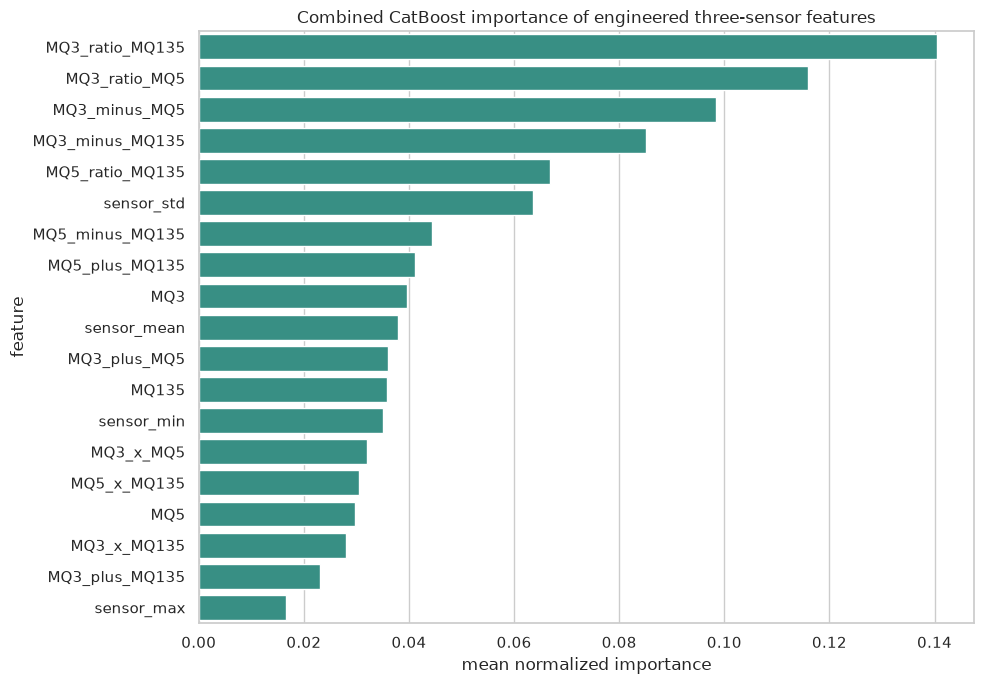

In [ ]:
feature_rank_freshness_model = CatBoostClassifier(
    iterations=300, depth=8, learning_rate=0.08,
    loss_function='Logloss', verbose=False, random_seed=42,
    thread_count=-1, allow_writing_files=False
)
feature_rank_freshness_model.fit(X_three_train, y.iloc[train_idx])
feature_importance_table = pd.DataFrame({
    'feature': selected_three_sensor_features,
    'catboost_importance': feature_rank_freshness_model.feature_importances_
}).sort_values('catboost_importance', ascending=False).reset_index(drop=True)
display(feature_importance_table.round(4))
print('All model inputs are the agreed nine features; no 19-feature path is used.')

In [ ]:
def make_score_model(hidden_layers=(20, 10)):
    return Pipeline([
        ('scale', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=hidden_layers, activation='relu', alpha=0.001,
            batch_size=256, max_iter=300, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=15, random_state=42
        ))
    ])

score_models = {
    'CatBoost': feature_rank_freshness_model,
    'TinyML MLP': make_score_model()
}
score_rows = []
score_predictions = {}
for name, estimator in score_models.items():
    if name == 'TinyML MLP':
        estimator.fit(X_three_train, y.iloc[train_idx])
    score = np.clip(estimator.predict_proba(X_three_test)[:, 1], 0.0, 1.0)
    score_predictions[name] = score
    metrics = evaluate_freshness_score(y.iloc[test_idx], score)
    metrics['model'] = name
    metrics['feature_count'] = len(selected_three_sensor_features)
    score_rows.append(metrics)
score_results = pd.DataFrame(score_rows).sort_values('brier', ascending=True)
display(score_results[[
    'model', 'feature_count', 'brier', 'log_loss', 'ece_10', 'roc_auc',
    'average_precision', 'mae', 'rmse', 'r2', 'threshold_accuracy',
    'balanced_accuracy', 'f1', 'score_min', 'score_max'
]].round(4))
best_score_model_name = score_results.iloc[0]['model']
best_score = score_predictions[best_score_model_name]
print(f'Best continuous-score model: {best_score_model_name}')

,feature_set,feature_count,freshness_accuracy,fruit_type_accuracy,joint_accuracy
0,all engineered features,19,0.903,0.887,0.808
1,CatBoost-selected features,9,0.905,0.862,0.788


Selected feature count: 9
Selected features: ['MQ3_ratio_MQ135', 'MQ3_ratio_MQ5', 'MQ3_minus_MQ5', 'MQ3_minus_MQ135', 'MQ5_ratio_MQ135', 'sensor_std', 'MQ5_minus_MQ135', 'MQ5_plus_MQ135', 'MQ3']
all engineered features: freshness=0.903, fruit=0.887, joint=0.808
CatBoost-selected features: freshness=0.905, fruit=0.862, joint=0.788


## 9. Conclusions and next steps

- `no_fruit.csv` is included in EDA as a reference recording but excluded from freshness training because it has no fresh/spoiled target.
- Supervised models use nine engineered features from `MQ3`, `MQ5`, and `MQ135`. The notebook currently swaps `MQ5`/`MQ135` on load; that assumption should be verified on hardware.
- Freshness models output a continuous score in `[0, 1]`. Primary metrics are **Brier**, **ROC-AUC**, and **ECE**; 0.5-threshold accuracy is only an optional display rule.
- CatBoost and TinyML MLP are compared on the same held-out temporal segments, including inference time.
- Before deployment: calibrate sensors, monitor drift, collect independent recording sessions, and prefer leave-one-fruit-out or leave-one-session-out validation over row sampling.


In [ ]:
import time

def benchmark_score(model, features, repetitions=30):
    for _ in range(3):
        model.predict_proba(features)
    durations = []
    for _ in range(repetitions):
        start = time.perf_counter()
        model.predict_proba(features)
        durations.append(time.perf_counter() - start)
    return float(np.median(durations))

inference_rows = []
for name, estimator in score_models.items():
    duration = benchmark_score(estimator, X_three_test)
    score = score_predictions[name]
    metrics = evaluate_freshness_score(y.iloc[test_idx], score)
    inference_rows.append({
        'model': name,
        'feature_count': len(selected_three_sensor_features),
        'brier': metrics['brier'],
        'roc_auc': metrics['roc_auc'],
        'ece_10': metrics['ece_10'],
        'mae': metrics['mae'],
        'rmse': metrics['rmse'],
        'r2': metrics['r2'],
        'score_min': metrics['score_min'],
        'score_max': metrics['score_max'],
        'batch_ms': duration * 1000,
        'per_sample_ms': duration * 1000 / len(X_three_test)
    })
inference_results = pd.DataFrame(inference_rows).sort_values('brier', ascending=True)
display(inference_results.round(4))

,model,feature_count,freshness_accuracy,fruit_type_accuracy,joint_accuracy,full_test_batch_ms,per_sample_ms,relative_to_tinyml_19x
0,TinyML - 19 features,19,0.9027,0.8868,0.8082,12.6996,0.0013,1.000
1,TinyML - 9 features,9,0.9051,0.8616,0.7876,11.9446,0.0012,0.941
2,CatBoost - 19 features,19,0.9341,0.8915,0.1214,16.3067,0.0017,1.284


9-feature TinyML latency change: -5.9%
